## BONARES Brandenburg 1: Analysis and Variable Selection for Stratified Soil Sampling

**Purpose**: Identify optimal variables for field stratification to capture SOC heterogeneity efficiently.

---

### Overview

This notebook identifies which remote sensing variables best predict SOC spatial variability for designing efficient stratified soil sampling strategies. We use three complementary approaches:

#### Workflow

**1. Data Loading & Preparation**
- Load SOC measurements and EO datacubes (Sentinel-1, Sentinel-2, DEM) from Bonares Farm 1 (5 fields (2017-2022))
- Extract variables at sampling locations using only data BEFORE sampling dates
- Focus on summer periods (June-August) with cloud-free observations

**2. Variable Generation**
- **Vegetation indices**: NDVI, EVI
- **Soil index**: BSI (Bare Soil Index)
- **Topography**: Elevation, Slope
- **Radar**: VV backscatter, VH/VV ratio

**3. Variable Selection - Three Approaches**
- **Approach 1**: Correlation analysis with SOC values (linear relationships)
- **Approach 2**: Random Forest variable importance (non-linear relationships & interactions)
- **Approach 3**: Clustering mimicry (how well variables reproduce SOC spatial patterns)

**4. Stratified Sampling Evaluation**
- Apply clustering from smartsampling.ipynb
- Evaluate how well stratification captures field heterogeneity

**Goal**: Variables that perform well across all three methods are robust candidates for stratification.

**Future Work:** This will have to be extended to Bonares Farm 2, which has many more additional fields. This is only a start in that workflow. Really dig into the clustering and homo vs. heterogeneity of the fields and try to find the best mechanism to match it. This notebook is a start, a brainstorm kickoff, but there are still many limitations and the content should be taken with a large grain of salt ;)

---

In [16]:
# Import libraries
import os  
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from shapely.geometry import box, Point
import geopandas as gpd
from pathlib import Path

import xarray as xr

# RF
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

#from scipy import stats
from statsmodels.tsa.seasonal import STL
from scipy import stats as scipy_stats

## 1. Data Loading & Preparation

### 1.1 Load SOC Measurements and Datacubes

In [17]:
# Load Brandenburg Farm 1 carbon data
data_path = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1/csv_files"
df_carbon = pd.read_csv(f"{data_path}/brandenburg1_carbon_df.csv")

# Convert dates to datetime
df_carbon['date_sampling'] = pd.to_datetime(df_carbon['date_sampling'])
df_carbon['date_lab_delivery'] = pd.to_datetime(df_carbon['date_lab_delivery'])

print(f"Loaded {len(df_carbon)} carbon measurements")
print(f"Fields: {sorted(df_carbon['field_ID_qgis'].unique())}")

Loaded 444 carbon measurements
Fields: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [18]:
# Load datacubes
cube_base_path = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/BONARES/Brandenburg_1"

datacubes = {}
for field_num in range(1, 6):
    cube_file = Path(f"{cube_base_path}/scaled_fused_field{field_num}_S1-S2-DEM_2017-2022_cube.nc")
    
    if cube_file.exists():
        datacubes[field_num] = xr.open_dataset(cube_file)
        print(f" Loaded field {field_num}: {datacubes[field_num].dims}")
    else:
        print(f"s File not found: {cube_file.name}")

print(f"\nSuccessfully loaded {len(datacubes)} datacubes")

 Loaded field 1: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 53, 'x': 74})
 Loaded field 2: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 29, 'x': 100})
 Loaded field 3: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 67, 'x': 67})
 Loaded field 4: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 68, 'x': 48})
 Loaded field 5: FrozenMappingWarningOnValuesAccess({'t': 2191, 'y': 88, 'x': 66})

Successfully loaded 5 datacubes


**Key Questions:**
- How stable are EO variables over time?
- Should we use data from the exact sampling date, same summer, or previous years?
- If variables vary strongly, which time horizons are appropriate?

**Variables to evaluate:**
- Vegetation indices: NDVI, EVI
- Soil index: BSI
- Topography: Elevation, Slope
- Radar: VV backscatter, VH/VV ratio

In [19]:
# Split into SOC and TOC dataframes for focused analysis
df_soc = df_carbon[df_carbon['parameter'] == 'Soil organic carbon'].copy()
df_toc = df_carbon[df_carbon['parameter'] == 'Total carbon'].copy()

print(f"SOC measurements: {len(df_soc)}")
print(f"TOC measurements: {len(df_toc)}")
print(f"\nSOC value range: {df_soc['value'].min():.2f} - {df_soc['value'].max():.2f}%")

# Create field-specific SOC datasets
soc_by_field = {field: df_soc[df_soc['field_ID_qgis'] == field].copy() 
                for field in sorted(df_soc['field_ID_qgis'].unique())}

# Summary statistics
stats = df_soc.groupby('field_ID_qgis')['value'].agg(['count', 'mean', 'std'])
stats['cv'] = (stats['std'] / stats['mean'] * 100)

print(f"\nSOC samples per field:")
for field_num in stats.index:
    cube_status = 'with datacube' if field_num in datacubes else 'NO datacube'
    print(f"  Field {field_num}: n={int(stats.loc[field_num, 'count'])}, "
          f"mean={stats.loc[field_num, 'mean']:.2f}%, "
          f"CV={stats.loc[field_num, 'cv']:.1f}% ({cube_status})")

SOC measurements: 222
TOC measurements: 222

SOC value range: 0.42 - 2.20%

SOC samples per field:
  Field 1: n=40, mean=0.93%, CV=15.3% (with datacube)
  Field 2: n=40, mean=0.76%, CV=15.4% (with datacube)
  Field 3: n=85, mean=0.92%, CV=34.2% (with datacube)
  Field 4: n=20, mean=0.61%, CV=24.8% (with datacube)
  Field 5: n=37, mean=0.71%, CV=22.0% (with datacube)


### 1.2 SOC Spatial Distribution

Visualize SOC values across fields to understand within-field heterogeneity.

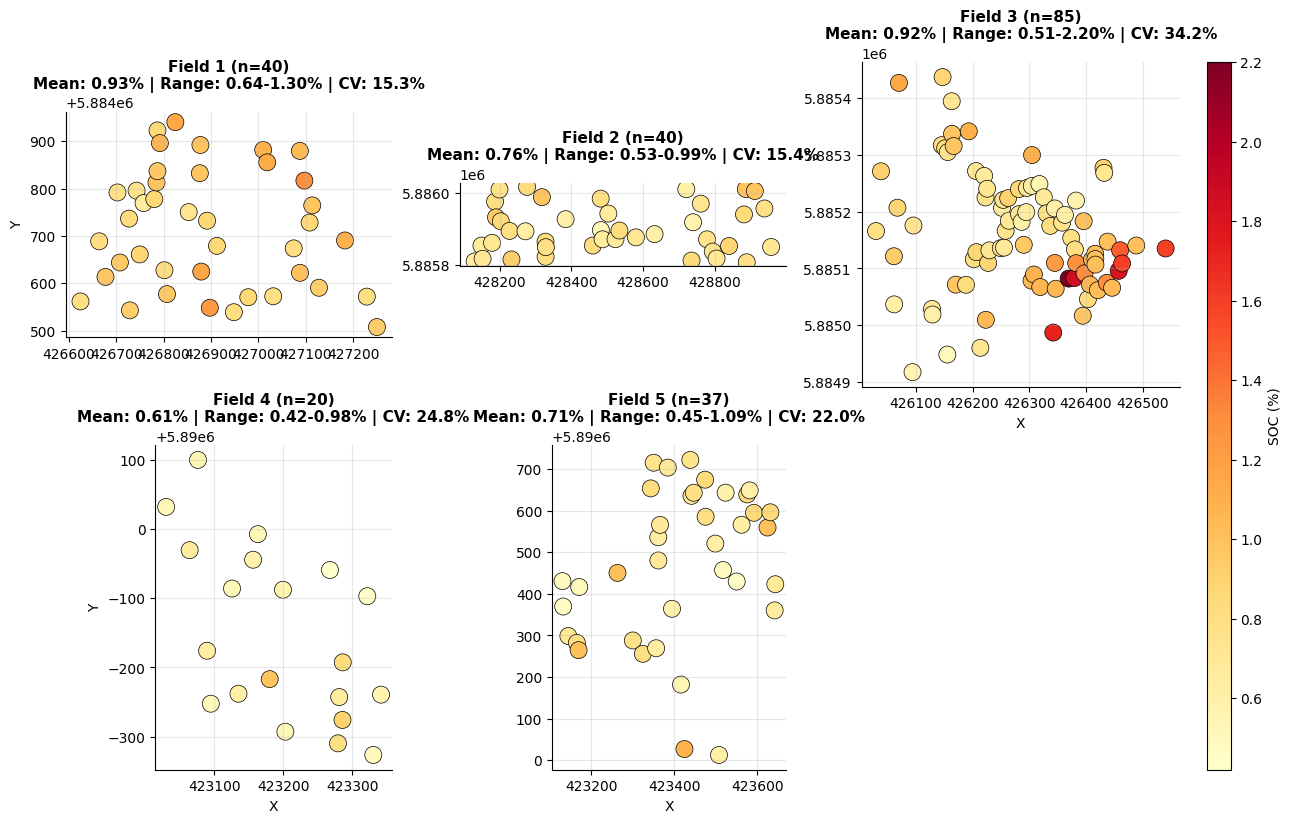

In [20]:
# Create individual SOC heatmaps for each field

# Calculate statistics per field for titles
stats = df_soc.groupby('field_ID_qgis')['value'].agg(['count', 'mean', 'std', 'min', 'max'])
stats['cv'] = (stats['std'] / stats['mean'] * 100)

# Create FacetGrid
g = sns.FacetGrid(df_soc, col='field_ID_qgis', col_wrap=3, height=4, aspect=1.2, 
                  sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x='X', y='Y', hue='value', palette='YlOrRd', 
                s=150, edgecolor='black', linewidth=0.5, 
                hue_norm=(df_soc['value'].min(), df_soc['value'].max()), legend=False)

# Add titles with statistics
for ax, (field_id, field_stats) in zip(g.axes.flat, stats.iterrows()):
    ax.set_title(f'Field {field_id} (n={int(field_stats["count"])})\n' + 
                f'Mean: {field_stats["mean"]:.2f}% | Range: {field_stats["min"]:.2f}-{field_stats["max"]:.2f}% | CV: {field_stats["cv"]:.1f}%',
                fontweight='bold', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# Add colorbar
norm = plt.Normalize(df_soc['value'].min(), df_soc['value'].max())
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
g.figure.colorbar(sm, ax=g.axes, label='SOC (%)', pad=0.02, aspect=30)

plt.show()

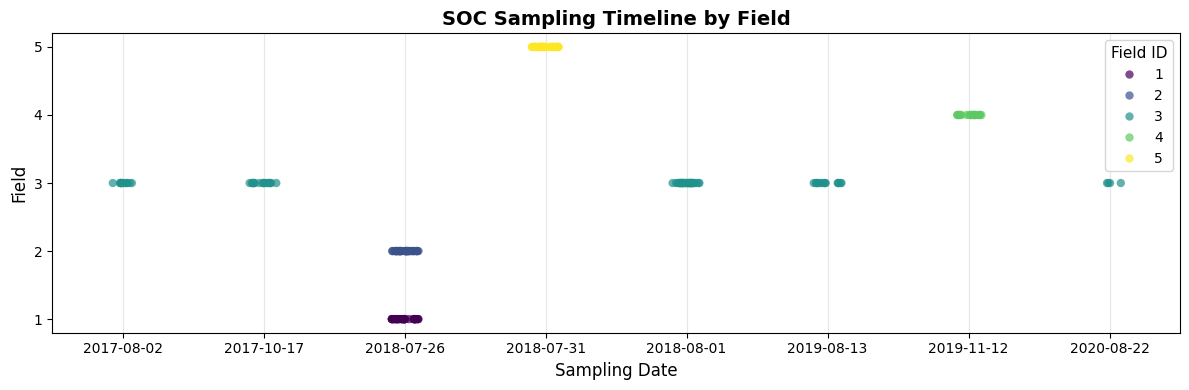

In [21]:
# Timeline visualization of sampling dates
fig, ax = plt.subplots(figsize=(12, 4))

# Strip plot showing when samples were taken, colored by field
sns.stripplot(data=df_soc.sort_values('date_sampling'), x='date_sampling', y='field_ID_qgis', 
              hue='field_ID_qgis', palette='viridis', size=6, alpha=0.7, ax=ax)

ax.set_xlabel('Sampling Date', fontsize=12)
ax.set_ylabel('Field', fontsize=12)
ax.set_title('SOC Sampling Timeline by Field', fontweight='bold', fontsize=14)
ax.legend(title='Field ID', title_fontsize=11, fontsize=10, loc='upper right')
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Variable Generation

Calculate environmental variables from EO datacubes for each SOC sampling point.

### 2.1 Index Calculation Functions

Define functions to calculate vegetation, soil, and topographic indices.

### 3 - Extract Key Variables for Stratification

**Goal**: In a first step extract 7 variables for visual correlation analysis with SOC. (Of course this can be scaled up later on.)

**Time Restriction**: Only use data BEFORE sampling date (vegetation AFTER sampling didn't cause SOC)

**Variable Selection:**

1. **NDVI** (summer mean, before sampling)
2. **EVI** (summer median, before sampling)
3. **BSI** Bare Soil Index (summer mean)
4. **Elevation** (from DEM)
5. **Slope** (calculate from elevation)
6. **VV backscatter** (summer mean) - Radar surface roughness
7. **VH/VV ratio** (summer mean) - Radar vegetation structure

In [22]:
# Index calculation functions
def calc_ndvi(ds):
    """Normalized Difference Vegetation Index"""
    return (ds['B08'] - ds['B04']) / (ds['B08'] + ds['B04'])

def calc_evi(ds):
    """Enhanced Vegetation Index"""
    # EVI = 2.5 * ((NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1))
    return 2.5 * ((ds['B08'] - ds['B04']) / (ds['B08'] + 6*ds['B04'] - 7.5*ds['B02'] + 1))

def calc_bsi(ds):
    """Bare Soil Index"""
    # BSI = ((SWIR + Red) - (NIR + Blue)) / ((SWIR + Red) + (NIR + Blue))
    return ((ds['B11'] + ds['B04']) - (ds['B08'] + ds['B02'])) / ((ds['B11'] + ds['B04']) + (ds['B08'] + ds['B02']))

def calc_slope(dem):
    """Calculate slope from DEM in degrees"""
    # Take temporal mean if time dimension exists
    if len(dem.dims) > 2:
        dem_2d = dem.mean(dim='t')
    else:
        dem_2d = dem
    
    # Calculate gradients
    dy, dx = np.gradient(dem_2d.values)
    
    # Get pixel resolution
    x_res = abs(float(dem_2d.x[1] - dem_2d.x[0]))
    y_res = abs(float(dem_2d.y[1] - dem_2d.y[0]))
    
    # Calculate slope
    slope_rad = np.arctan(np.sqrt((dy/y_res)**2 + (dx/x_res)**2))
    slope_deg = np.degrees(slope_rad)
    
    return xr.DataArray(slope_deg, coords=dem_2d.coords, dims=dem_2d.dims)

print("Index calculation functions defined")

Index calculation functions defined


### 2.2 Temporal NDVI Analysis

Analyze NDVI variation over time to assess variable stability for stratification.

In [23]:
# Analyze temporal NDVI variation for each field
print("TEMPORAL NDVI ANALYSIS BY FIELD\n")

# For each field with datacube, extract NDVI time series as FIELD AVERAGE
ndvi_timeseries = {}

for field_num in sorted(datacubes.keys()):
    print(f"Processing Field {field_num}...")
    ds = datacubes[field_num]
    
    # Calculate NDVI for entire field (all pixels, all timesteps)
    ndvi_field = (ds['B08'] - ds['B04']) / (ds['B08'] + ds['B04'])
    
    # Take spatial mean across x and y dimensions for each timestep
    # This gives field-average NDVI per date (more representative than single pixel!)
    ndvi_ts = ndvi_field.mean(dim=['x', 'y'])
    
    # Convert to pandas DataFrame for easier plotting
    df_ndvi = pd.DataFrame({
        'date': pd.to_datetime(ndvi_ts.t.values),
        'NDVI': ndvi_ts.values,
        'field': field_num
    })
    
    # Remove NaN values (timesteps where entire field was cloudy)
    df_ndvi = df_ndvi.dropna()
    
    # Add year and month for grouping
    df_ndvi['year'] = df_ndvi['date'].dt.year
    df_ndvi['month'] = df_ndvi['date'].dt.month
    df_ndvi['year_month'] = df_ndvi['date'].dt.to_period('M')
    
    ndvi_timeseries[field_num] = df_ndvi
    print(f"  {len(df_ndvi)} valid NDVI observations from {df_ndvi['date'].min().date()} to {df_ndvi['date'].max().date()}")

print(f"\n Extracted NDVI time series for {len(ndvi_timeseries)} fields")

TEMPORAL NDVI ANALYSIS BY FIELD

Processing Field 1...
  296 valid NDVI observations from 2017-01-04 to 2022-12-09
Processing Field 2...
  298 valid NDVI observations from 2017-01-04 to 2022-12-27
Processing Field 3...
  300 valid NDVI observations from 2017-01-04 to 2022-12-09
Processing Field 4...
  289 valid NDVI observations from 2017-01-04 to 2022-12-27
Processing Field 5...
  315 valid NDVI observations from 2017-01-04 to 2022-12-27

 Extracted NDVI time series for 5 fields


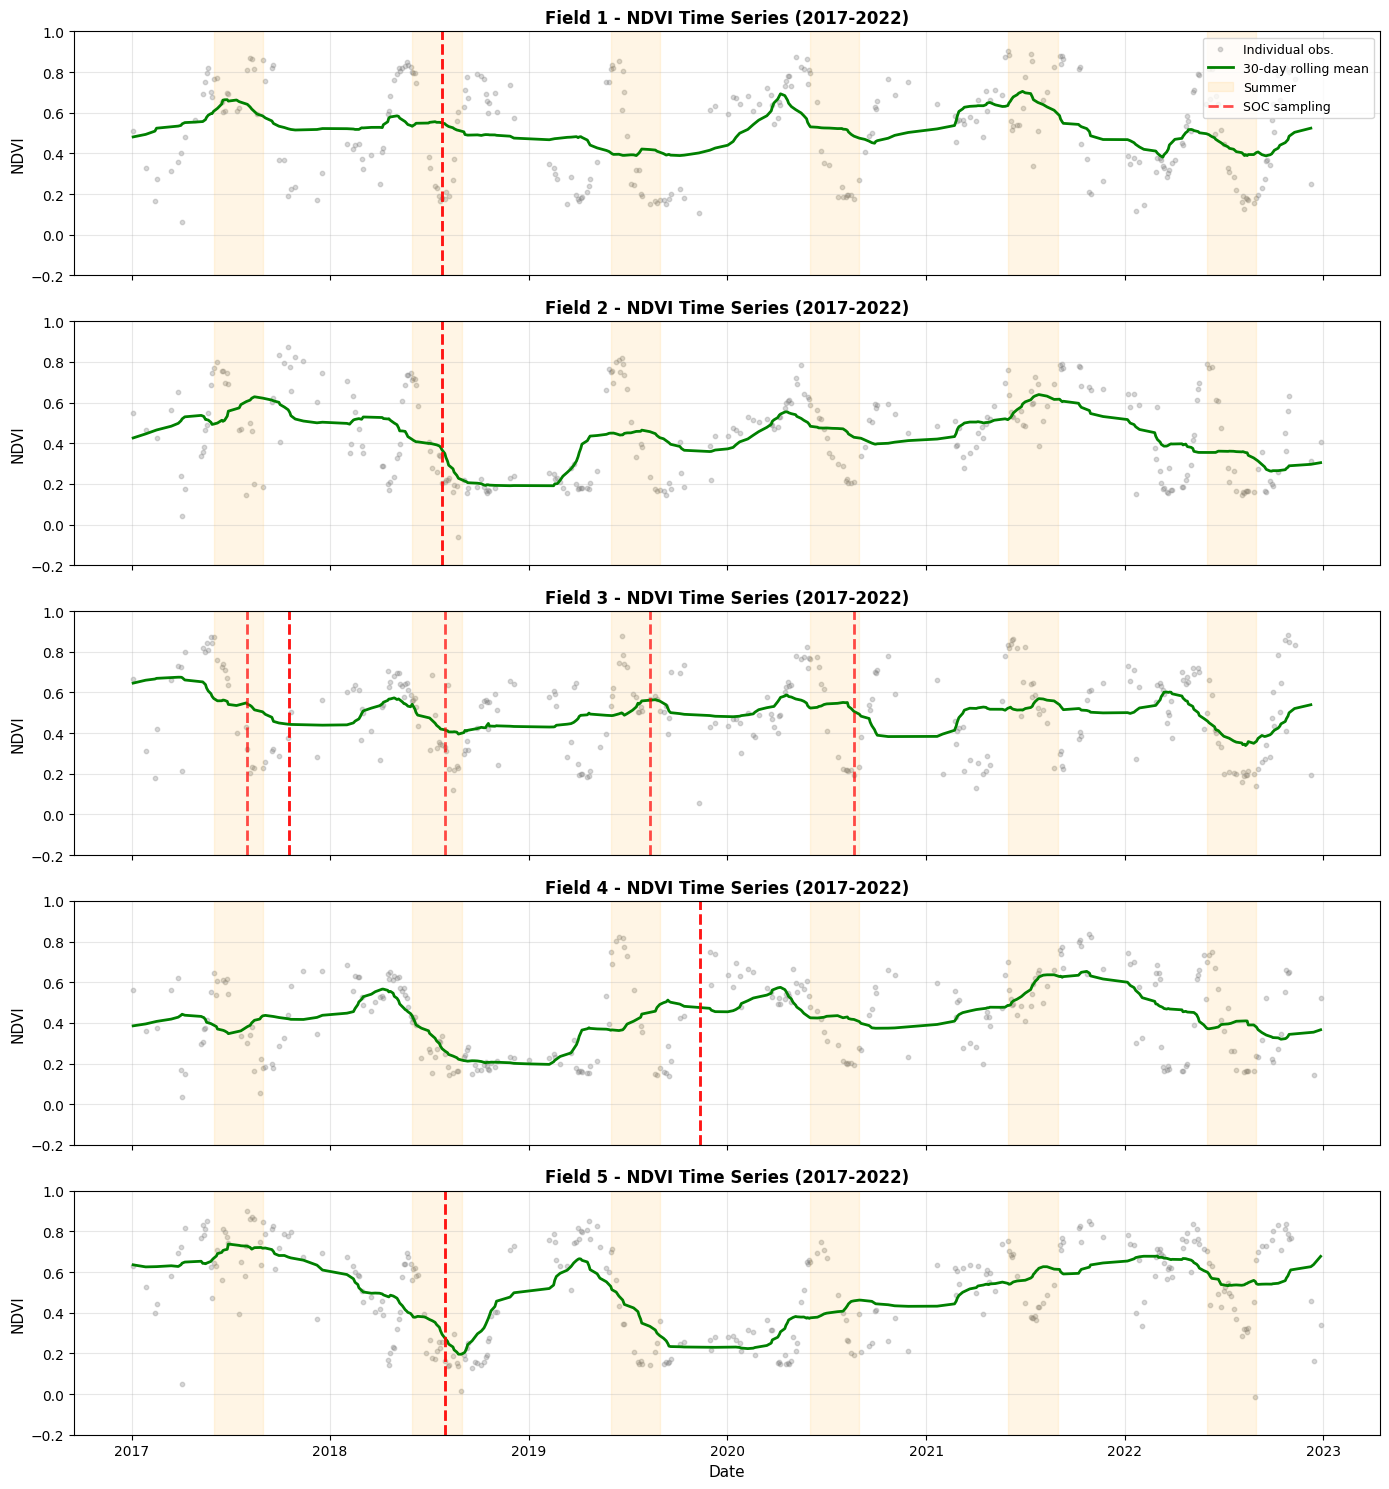

In [24]:
# 1. Time series plot: NDVI evolution over time for each field
fig, axes = plt.subplots(len(ndvi_timeseries), 1, figsize=(14, 3*len(ndvi_timeseries)), sharex=True)

if len(ndvi_timeseries) == 1:
    axes = [axes]

for idx, (field_num, df) in enumerate(sorted(ndvi_timeseries.items())):
    ax = axes[idx]
    
    # Plot all observations
    ax.scatter(df['date'], df['NDVI'], alpha=0.3, s=10, c='gray', label='Individual obs.')
    
    # Plot monthly rolling mean to show trend
    df_sorted = df.sort_values('date')
    df_sorted['NDVI_smooth'] = df_sorted['NDVI'].rolling(window=30, center=True, min_periods=1).mean()
    ax.plot(df_sorted['date'], df_sorted['NDVI_smooth'], color='green', linewidth=2, label='30-day rolling mean')
    
    # Mark summer periods
    for year in df['year'].unique():
        summer_start = pd.Timestamp(f'{year}-06-01')
        summer_end = pd.Timestamp(f'{year}-08-31')
        ax.axvspan(summer_start, summer_end, alpha=0.1, color='orange', label='Summer' if year == df['year'].min() else '')
    
    # Add SOC sampling dates if available
    if field_num in soc_by_field:
        sampling_dates = soc_by_field[field_num]['date_sampling'].unique()
        for date in sampling_dates:
            ax.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7, linewidth=2)
        ax.axvline(pd.Timestamp(sampling_dates[0]), color='red', linestyle='--', alpha=0.7, linewidth=2, label='SOC sampling')
    
    ax.set_ylabel('NDVI', fontsize=11)
    ax.set_title(f'Field {field_num} - NDVI Time Series (2017-2022)', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.2, 1.0)
    
    # Only show legend for first plot
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

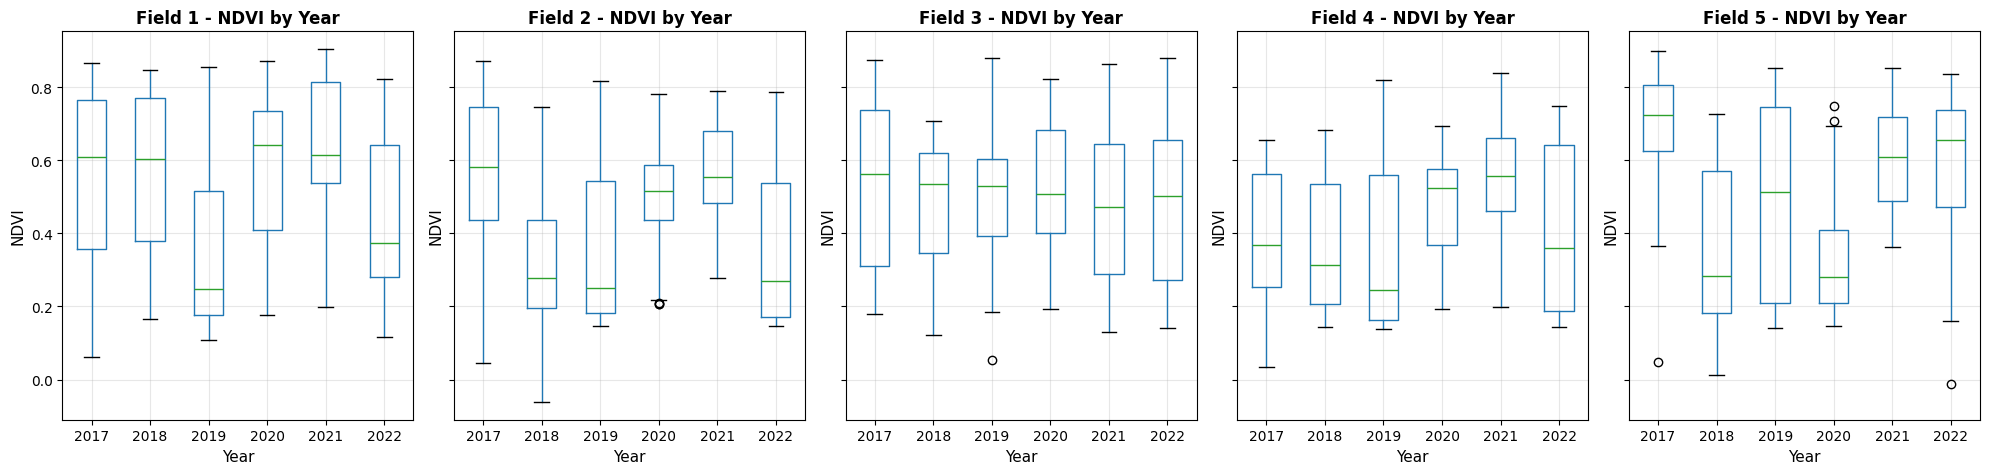

In [25]:
# 2. Boxplots: NDVI distribution by year for each field
fig, axes = plt.subplots(1, len(ndvi_timeseries), figsize=(4*len(ndvi_timeseries), 5), sharey=True)

if len(ndvi_timeseries) == 1:
    axes = [axes]

for idx, (field_num, df) in enumerate(sorted(ndvi_timeseries.items())):
    ax = axes[idx]
    
    # Create boxplot grouped by year
    df.boxplot(column='NDVI', by='year', ax=ax)
    
    # Styling
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('NDVI', fontsize=11)
    ax.set_title(f'Field {field_num} - NDVI by Year', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.sca(ax)
    plt.xticks(rotation=0)
    
    # Remove automatic title from pandas
    ax.get_figure().suptitle('')

axes[0].set_ylabel('NDVI', fontsize=11)
plt.tight_layout()
plt.show()

In [26]:
# 3. Summary statistics: Inter-annual and intra-annual variability
print("\n NDVI VARIABILITY SUMMARY\n")

for field_num, df in sorted(ndvi_timeseries.items()):
    print(f"\nField {field_num}:")
    print(f"  Overall NDVI: {df['NDVI'].mean():.3f} ± {df['NDVI'].std():.3f} (CV: {df['NDVI'].std()/df['NDVI'].mean()*100:.1f}%)")
    
    # Annual statistics
    annual_stats = df.groupby('year')['NDVI'].agg(['mean', 'std', 'min', 'max'])
    print(f"\n  Annual variation:")
    for year, row in annual_stats.iterrows():
        print(f"    {year}: mean={row['mean']:.3f}, std={row['std']:.3f}, range=[{row['min']:.3f}, {row['max']:.3f}]")
    
    # Summer vs non-summer
    df_summer = df[df['month'].isin([6, 7, 8])]
    df_nonsummer = df[~df['month'].isin([6, 7, 8])]
    
    if len(df_summer) > 0:
        print(f"\n  Summer (Jun-Aug): mean={df_summer['NDVI'].mean():.3f}, std={df_summer['NDVI'].std():.3f}")
    if len(df_nonsummer) > 0:
        print(f"  Non-summer:       mean={df_nonsummer['NDVI'].mean():.3f}, std={df_nonsummer['NDVI'].std():.3f}")



 NDVI VARIABILITY SUMMARY


Field 1:
  Overall NDVI: 0.516 ± 0.236 (CV: 45.8%)

  Annual variation:
    2017: mean=0.561, std=0.238, range=[0.062, 0.868]
    2018: mean=0.558, std=0.224, range=[0.166, 0.847]
    2019: mean=0.357, std=0.240, range=[0.107, 0.856]
    2020: mean=0.574, std=0.216, range=[0.176, 0.873]
    2021: mean=0.629, std=0.188, range=[0.200, 0.905]
    2022: mean=0.439, std=0.214, range=[0.116, 0.824]

  Summer (Jun-Aug): mean=0.478, std=0.256
  Non-summer:       mean=0.535, std=0.223

Field 2:
  Overall NDVI: 0.438 ± 0.213 (CV: 48.7%)

  Annual variation:
    2017: mean=0.555, std=0.217, range=[0.044, 0.871]
    2018: mean=0.349, std=0.205, range=[-0.062, 0.746]
    2019: mean=0.369, std=0.237, range=[0.146, 0.817]
    2020: mean=0.489, std=0.137, range=[0.206, 0.782]
    2021: mean=0.569, std=0.138, range=[0.277, 0.789]
    2022: mean=0.348, std=0.201, range=[0.147, 0.787]

  Summer (Jun-Aug): mean=0.453, std=0.228
  Non-summer:       mean=0.430, std=0.205

Field 

#### Advanced Temporal Analysis

Use spatial and temporal analysis functions to identify NDVI patterns, hotspots, and trends.

In [27]:
def spatial_analysis(data, value_col=None, hotspot_type='high', factor=2):
    """Analyze spatial variability at each timestamp and identify hotspots."""
    # Convert DataArray to DataFrame if needed
    if hasattr(data, 'to_dataframe'):
        df = data.to_dataframe(name=value_col or data.name).reset_index()
        value_col = value_col or data.name
    else:
        df = data.copy()
    
    # Compute spatial statistics per timestamp
    spatial_stats = df.groupby('t')[value_col].agg(['mean', 'std', 'min', 'max']).reset_index()
    
    # Identify hotspots
    df_merged = df.merge(spatial_stats, on='t', suffixes=('', '_spatial'))
    threshold_col = 'mean' if hotspot_type == 'high' else 'mean'
    
    if hotspot_type == 'high':
        hotspots = df_merged[df_merged[value_col] > (df_merged['mean'] + factor * df_merged['std'])]
    else:
        hotspots = df_merged[df_merged[value_col] < (df_merged['mean'] - factor * df_merged['std'])]
    
    return spatial_stats, hotspots

def temporal_analysis_pixel(da, slope_significance=0.05):
    """Analyze temporal patterns for each pixel using linear regression."""
    # Convert to DataFrame
    df = da.to_dataframe(name='NDVI').reset_index()
    df['days'] = (df['t'] - df['t'].min()).dt.days
    
    pixel_trends = []
    
    for (y, x), group in df.groupby(['y', 'x']):
        if len(group) < 10:  # Need minimum observations
            continue
        
        # Remove NaN
        valid = group.dropna(subset=['NDVI'])
        if len(valid) < 10:
            continue
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(valid['days'], valid['NDVI'])
        
        # Classify trend
        if p_value < slope_significance:
            trend = 'increasing' if slope > 0 else 'decreasing'
        else:
            trend = 'stable'
        
        pixel_trends.append({
            'y': y, 'x': x,
            'mean': valid['NDVI'].mean(),
            'std': valid['NDVI'].std(),
            'slope': slope,
            'p_value': p_value,
            'r_squared': r_value**2,
            'trend': trend
        })
    
    return pd.DataFrame(pixel_trends)

print("Analysis functions loaded")

Analysis functions loaded


In [28]:
# Apply temporal trend analysis to one field
if len(datacubes) > 0:
    field_num = 1
    print(f"TEMPORAL TREND ANALYSIS - Field {field_num}\n")
    
    ds = datacubes[field_num]
    
    # Calculate NDVI for entire field
    ndvi_field = (ds['B08'] - ds['B04']) / (ds['B08'] + ds['B04'])
    
    # Run pixel-level trend analysis
    print("Analyzing temporal trends per pixel...")
    trends = temporal_analysis_pixel(ndvi_field, slope_significance=0.05)
    
    print(f"\n Analyzed {len(trends)} pixels")
    print(f"\nTrend classification:")
    print(trends['trend'].value_counts())
    
    print(f"\nSlope statistics (NDVI change per day):")
    print(f"  Mean slope: {trends['slope'].mean():.6f}")
    print(f"  Median slope: {trends['slope'].median():.6f}")
    print(f"  Range: [{trends['slope'].min():.6f}, {trends['slope'].max():.6f}]")
    
    print(f"\nAverage R²: {trends['r_squared'].mean():.3f}")

TEMPORAL TREND ANALYSIS - Field 1

Analyzing temporal trends per pixel...

 Analyzed 2495 pixels

Trend classification:
trend
stable        2314
decreasing     181
Name: count, dtype: int64

Slope statistics (NDVI change per day):
  Mean slope: -0.000030
  Median slope: -0.000031
  Range: [-0.000070, 0.000014]

Average R²: 0.007


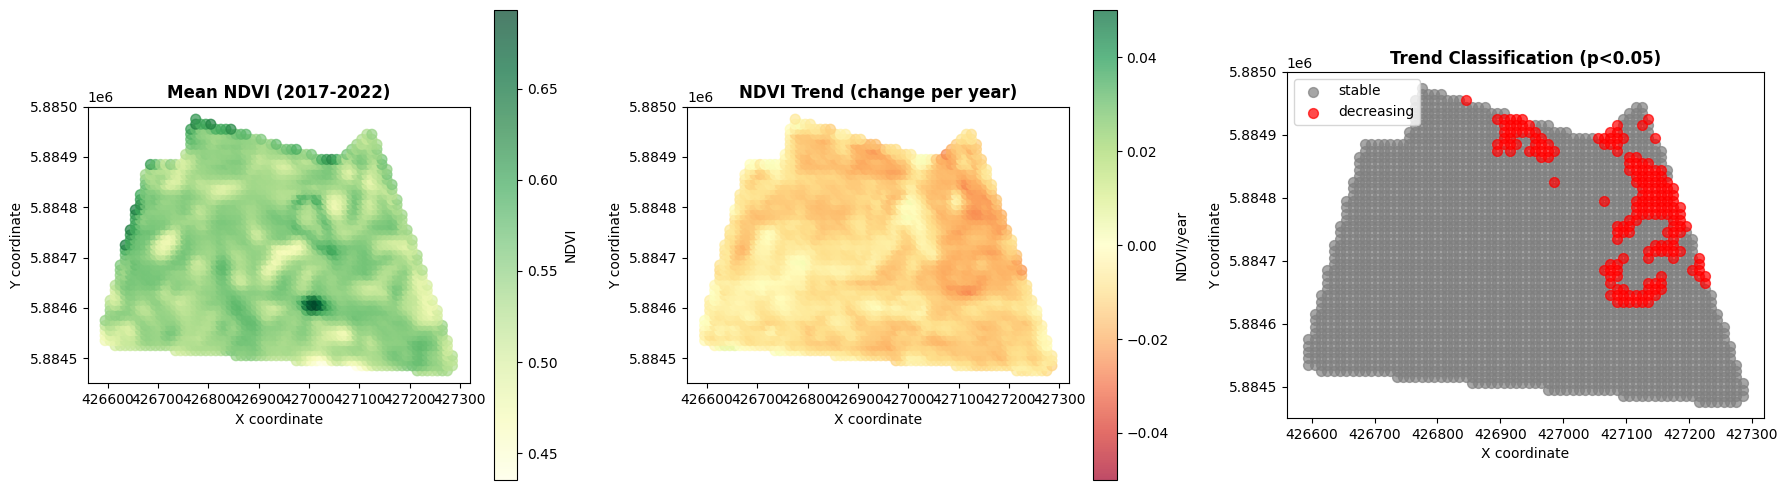

In [29]:
# Visualize spatial pattern of temporal trends
if len(datacubes) > 0 and len(trends) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Mean NDVI map
    ax = axes[0]
    scatter = ax.scatter(trends['x'], trends['y'], c=trends['mean'], 
                        cmap='YlGn', s=50, alpha=0.7)
    ax.set_title('Mean NDVI (2017-2022)', fontweight='bold', fontsize=12)
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_aspect('equal')
    plt.colorbar(scatter, ax=ax, label='NDVI')
    
    # 2. Trend slope map
    ax = axes[1]
    scatter = ax.scatter(trends['x'], trends['y'], c=trends['slope']*365, 
                        cmap='RdYlGn', s=50, alpha=0.7, vmin=-0.05, vmax=0.05)
    ax.set_title('NDVI Trend (change per year)', fontweight='bold', fontsize=12)
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_aspect('equal')
    plt.colorbar(scatter, ax=ax, label='NDVI/year')
    
    # 3. Trend classification map
    ax = axes[2]
    trend_colors = {'increasing': 'green', 'stable': 'gray', 'decreasing': 'red'}
    for trend_type, color in trend_colors.items():
        subset = trends[trends['trend'] == trend_type]
        if len(subset) > 0:
            ax.scatter(subset['x'], subset['y'], c=color, s=50, 
                      alpha=0.7, label=trend_type)
    ax.set_title('Trend Classification (p<0.05)', fontweight='bold', fontsize=12)
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

**Interpretation:**
- **Mean NDVI**: Shows overall vegetation patterns across the field
- **Trend slope**: Areas with increasing (green) or decreasing (red) NDVI over time
- **Trend classification**: Identifies statistically significant trends (p<0.05)

**Implications for stratification:**
- Stable patterns → NDVI is reliable for stratification
- Dynamic areas → May need multi-year averaging or alternative variables

### 2.3 Extract Variables at Sampling Locations

Extract 7 key variables for each SOC sampling point using **only data BEFORE sampling date**.

In [30]:
# Extract 7 variables for all SOC points in all fields
soc_variables = {}

for field_num in sorted(soc_by_field.keys()):
    if field_num not in datacubes:
        print(f"Field {field_num}: No datacube, skipping")
        continue
    
    print(f"\nField {field_num}...")
    ds_field = datacubes[field_num]
    field_soc = soc_by_field[field_num]
    
    # Check for DEM variable
    if 'DEM' not in ds_field:
        print(f"No DEM in datacube, skipping field")
        continue
    
    # Pre-calculate slope for entire field (only once)
    slope_field = calc_slope(ds_field['DEM'])
    print(f"Calculated slope for field")
    
    # Extract for each point
    field_data = []
    n_no_data = 0
    
    for idx, point in field_soc.iterrows():
        # Get data at point location
        try:
            point_data = ds_field.sel(x=point['X'], y=point['Y'], method='nearest')
        except Exception as e:
            print(f"Point {point['point_ID']}: Error selecting point - {e}")
            n_no_data += 1
            continue
        
        # Filter to BEFORE sampling date
        sampling_date = pd.Timestamp(point['date_sampling']).to_datetime64()
        point_before = point_data.sel(t=point_data['t'] < sampling_date)
        
        if len(point_before['t']) == 0:
            n_no_data += 1
            continue
        
        # Filter to summer months (June-Aug)
        is_summer = point_before['t'].dt.month.isin([6, 7, 8])
        summer = point_before.sel(t=is_summer)
        
        if len(summer['t']) == 0:
            n_no_data += 1
            continue
        
        # Filter to valid Sentinel-2 data (non-NaN B08)
        valid_s2 = ~np.isnan(summer['B08'])
        summer_valid = summer.sel(t=valid_s2)
        
        if len(summer_valid['t']) == 0:
            n_no_data += 1
            continue
        
        # Calculate indices
        ndvi = calc_ndvi(summer_valid)
        evi = calc_evi(summer_valid)
        bsi = calc_bsi(summer_valid)
        
        # Get slope at point
        slope_at_point = slope_field.sel(x=point['X'], y=point['Y'], method='nearest')
        
        # Extract variables
        point_vars = {
            'point_ID': point['point_ID'],
            'SOC_value': point['value'],
            'date_sampling': point['date_sampling'],
            'X': point['X'],
            'Y': point['Y'],
            'n_observations': len(summer_valid['t']),
            'NDVI_summer_mean': float(ndvi.mean().values),
            'EVI_summer_median': float(evi.median().values),
            'BSI_summer_mean': float(bsi.mean().values),
            'Elevation': float(summer_valid['DEM'].mean().values),
            'Slope': float(slope_at_point.mean().values),
            'VV_summer_mean': float(summer_valid['VV'].mean().values) if 'VV' in summer_valid else np.nan,
            'VH_VV_ratio': float((summer_valid['VH'] / summer_valid['VV']).mean().values) if 'VH' in summer_valid and 'VV' in summer_valid else np.nan
        }
        
        field_data.append(point_vars)
    
    # Convert to DataFrame
    soc_variables[field_num] = pd.DataFrame(field_data)
    print(f"Extracted 7 variables for {len(field_data)} points")
    if n_no_data > 0:
        print(f"  {n_no_data} points had no valid data")

print(f"\n Complete. Extracted for {len(soc_variables)} fields")


Field 1...
Calculated slope for field
Extracted 7 variables for 40 points

Field 2...
Calculated slope for field
Extracted 7 variables for 40 points

Field 3...
Calculated slope for field
Extracted 7 variables for 85 points

Field 4...
Calculated slope for field
Extracted 7 variables for 20 points

Field 5...
Calculated slope for field
Extracted 7 variables for 37 points

 Complete. Extracted for 5 fields


In [31]:
# Quick look at extracted data
print(" EXTRACTION SUMMARY \n")

# Check which fields have data
for field_num in sorted(soc_variables.keys()):
    n_extracted = len(soc_variables[field_num])
    n_total = len(soc_by_field[field_num])
    pct = (n_extracted / n_total * 100) if n_total > 0 else 0
    print(f"Field {field_num}: {n_extracted}/{n_total} points extracted ({pct:.1f}%)")

# Show sample from first field with data
fields_with_data = [f for f in soc_variables.keys() if len(soc_variables[f]) > 0]

if len(fields_with_data) > 0:
    first_field = fields_with_data[0]
    print("-"*80)
    print(f"\n Sample from Field {first_field} ")
    print(soc_variables[first_field].head())
    print(f"\nShape: {soc_variables[first_field].shape}")
    print(f"\nVariable summary:")
    print(soc_variables[first_field].describe())
else:
    print("\n No data extracted for any field")

 EXTRACTION SUMMARY 

Field 1: 40/40 points extracted (100.0%)
Field 2: 40/40 points extracted (100.0%)
Field 3: 85/85 points extracted (100.0%)
Field 4: 20/20 points extracted (100.0%)
Field 5: 37/37 points extracted (100.0%)
--------------------------------------------------------------------------------

 Sample from Field 1 
   point_ID  SOC_value date_sampling         X          Y  n_observations  \
0       193       0.80    2018-07-26  426624.3  5884561.7              17   
1       194       0.81    2018-07-26  426663.8  5884688.6              18   
2       195       0.97    2018-07-26  426677.1  5884613.5              18   
3       196       0.78    2018-07-26  426702.4  5884791.7              20   
4       197       0.95    2018-07-26  426707.5  5884643.9              17   

   NDVI_summer_mean  EVI_summer_median  BSI_summer_mean  Elevation     Slope  \
0          0.534346           0.393287        -0.059840  68.033112  1.256009   
1          0.660451           0.620156        

## 3. Variable Selection - Three Approaches

Identify which variables best capture SOC spatial variability using complementary methods.

### 3.1 Approach 1: Correlation Analysis

Identify linear relationships between environmental variables and SOC values.

In [32]:
# Combine all fields data for overall correlation analysis
if len(fields_with_data) > 0:
    # Concatenate all fields together
    df_all = pd.concat([soc_variables[f] for f in fields_with_data], ignore_index=True)
    
    print(f" Combined dataset: {len(df_all)} sampling points across {len(fields_with_data)} field(s)")
    print(f"  Fields included: {fields_with_data}\n")
    
    # Identify the 7 environmental variables (exclude metadata and SOC_value itself)
    exclude_cols = ['point_ID', 'SOC_value', 'date_sampling', 'X', 'Y', 'n_observations']
    var_cols = [col for col in df_all.columns if col not in exclude_cols]
    
    print(f" Environmental variables (independent): {var_cols}")
    print(f" Target variable (dependent): SOC_value")
    print(f"\n  Goal: Find which environmental variables correlate with SOC heterogeneity")
else:
    print(" No data available for correlation analysis")

 Combined dataset: 222 sampling points across 5 field(s)
  Fields included: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

 Environmental variables (independent): ['NDVI_summer_mean', 'EVI_summer_median', 'BSI_summer_mean', 'Elevation', 'Slope', 'VV_summer_mean', 'VH_VV_ratio']
 Target variable (dependent): SOC_value

  Goal: Find which environmental variables correlate with SOC heterogeneity


In [33]:
# Calculate correlations: which environmental variables explain SOC variability?
print("Which variables correlate with SOC values?\n")

if len(fields_with_data) > 0:
    # Combine environmental variables WITH SOC_value for correlation analysis
    numeric_cols = var_cols + ['SOC_value']
    df_numeric = df_all[numeric_cols].copy()
    
    # Calculate full correlation matrix, then extract correlations with SOC_value
    correlations_with_soc = df_numeric.corr()['SOC_value'].drop('SOC_value').sort_values(ascending=False)
        
    for var, corr in correlations_with_soc.items():
        strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
        direction = "positive" if corr > 0 else "negative"
        print(f"{var:20s}: {corr:>6.3f}  ({strength} {direction})")


Which variables correlate with SOC values?

NDVI_summer_mean    :  0.317  (Moderate positive)
VV_summer_mean      :  0.316  (Moderate positive)
Elevation           :  0.313  (Moderate positive)
EVI_summer_median   :  0.295  (Weak positive)
VH_VV_ratio         : -0.042  (Weak negative)
Slope               : -0.224  (Weak negative)
BSI_summer_mean     : -0.358  (Moderate negative)


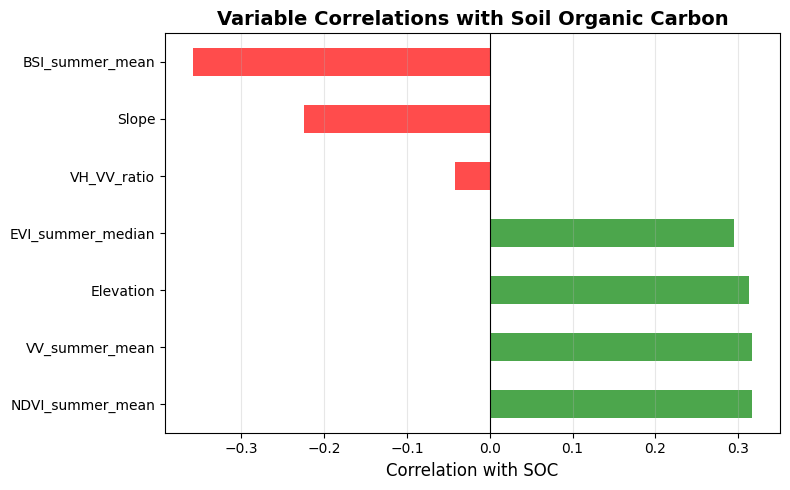

In [34]:
# Visualize correlations with SOC
if len(fields_with_data) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Create bar plot
    colors = ['green' if x > 0 else 'red' for x in correlations_with_soc.values]
    correlations_with_soc.plot(kind='barh', ax=ax, color=colors, alpha=0.7)
    
    ax.set_xlabel('Correlation with SOC', fontsize=12)
    ax.set_title('Variable Correlations with Soil Organic Carbon', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

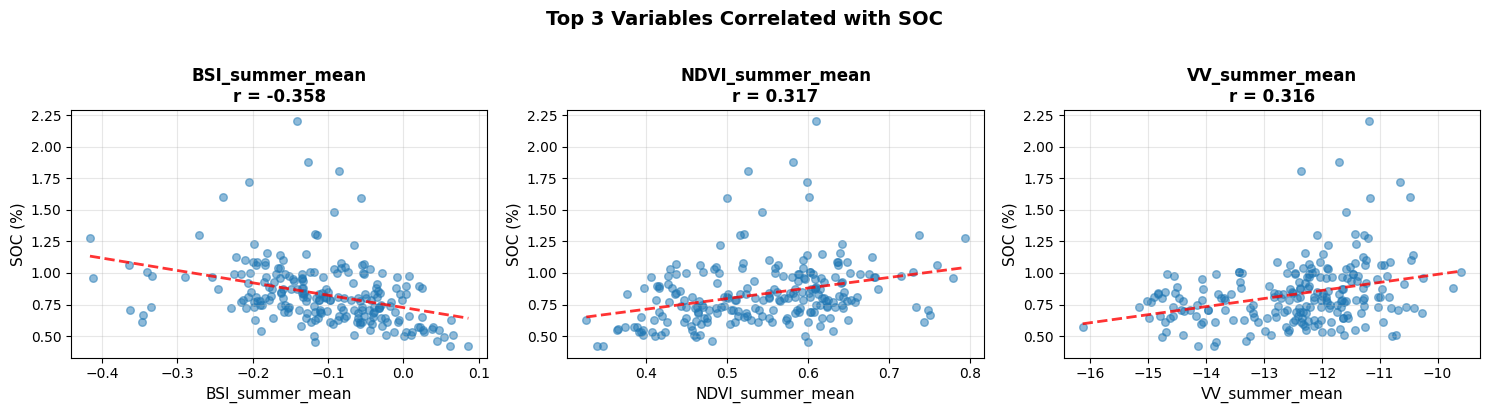

In [35]:
# Create scatter plots for top correlated variables
if len(fields_with_data) > 0:
    # Get top 3 absolute correlations
    top_vars = correlations_with_soc.abs().nlargest(3).index.tolist()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for i, var in enumerate(top_vars):
        ax = axes[i]
        
        # Scatter plot
        ax.scatter(df_all[var], df_all['SOC_value'], alpha=0.5, s=30)
        
        # Add trend line
        z = np.polyfit(df_all[var].dropna(), df_all.loc[df_all[var].notna(), 'SOC_value'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_all[var].min(), df_all[var].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Labels
        corr_val = correlations_with_soc[var]
        ax.set_xlabel(var, fontsize=11)
        ax.set_ylabel('SOC (%)', fontsize=11)
        ax.set_title(f'{var}\nr = {corr_val:.3f}', fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)
    
    plt.suptitle('Top 3 Variables Correlated with SOC', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 3.2 Approach 2: Random Forest Variable Importance

Use Random Forest to identify important variables and their combinations (captures non-linear relationships).

---

#### Random Forest Setup

In [36]:
# Prepare data for Random Forest
if len(fields_with_data) > 0:
    # Get variable columns (exclude metadata)
    exclude_cols = ['point_ID', 'SOC_value', 'date_sampling', 'X', 'Y', 'n_observations']
    var_cols = [col for col in df_all.columns if col not in exclude_cols]
    
    # Remove rows with NaN in any variable
    df_clean = df_all.dropna(subset=var_cols + ['SOC_value'])
    
    X = df_clean[var_cols].values
    y = df_clean['SOC_value'].values
    
    print(f"Random Forest Dataset:")
    print(f"  Samples: {len(df_clean)}")
    print(f"  Variables: {len(var_cols)}")
    print(f"  Variables: {var_cols}")
    print(f"\n  Target (SOC) range: {y.min():.2f} - {y.max():.2f}%")

Random Forest Dataset:
  Samples: 221
  Variables: 7
  Variables: ['NDVI_summer_mean', 'EVI_summer_median', 'BSI_summer_mean', 'Elevation', 'Slope', 'VV_summer_mean', 'VH_VV_ratio']

  Target (SOC) range: 0.42 - 2.20%


In [37]:
# Train Random Forest and get variable importance
if len(fields_with_data) > 0:
    # Initialize Random Forest
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    # Train model
    print("Training Random Forest...")
    rf.fit(X, y)
    
    # Get feature importance
    mdi_importance = pd.DataFrame({
        'variable': var_cols,
        'importance_MDI': rf.feature_importances_
    }).sort_values('importance_MDI', ascending=False)
    
    print("\n Feature Importance:\n")
    for _, row in mdi_importance.iterrows():
        print(f"  {row['variable']:20s}: {row['importance_MDI']:.4f}")
    

Training Random Forest...

 Feature Importance:

  Elevation           : 0.3223
  Slope               : 0.1701
  BSI_summer_mean     : 0.1684
  VV_summer_mean      : 0.1472
  NDVI_summer_mean    : 0.0699
  EVI_summer_median   : 0.0616
  VH_VV_ratio         : 0.0605


In [38]:
# Permutation importance (more robust measure)
if len(fields_with_data) > 0:
    print("Computing permutation importance...")
    perm_importance = permutation_importance(rf, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    
    perm_df = pd.DataFrame({
        'variable': var_cols,
        'importance_perm': perm_importance.importances_mean,
        'std': perm_importance.importances_std
    }).sort_values('importance_perm', ascending=False)
    
    print("\n Permutation Importance:\n")
    for _, row in perm_df.iterrows():
        print(f"  {row['variable']:20s}: {row['importance_perm']:.4f} ± {row['std']:.4f}")

Computing permutation importance...

 Permutation Importance:

  Elevation           : 0.4685 ± 0.0407
  BSI_summer_mean     : 0.2469 ± 0.0316
  VV_summer_mean      : 0.2116 ± 0.0284
  Slope               : 0.1764 ± 0.0136
  NDVI_summer_mean    : 0.0627 ± 0.0038
  VH_VV_ratio         : 0.0517 ± 0.0053
  EVI_summer_median   : 0.0513 ± 0.0033


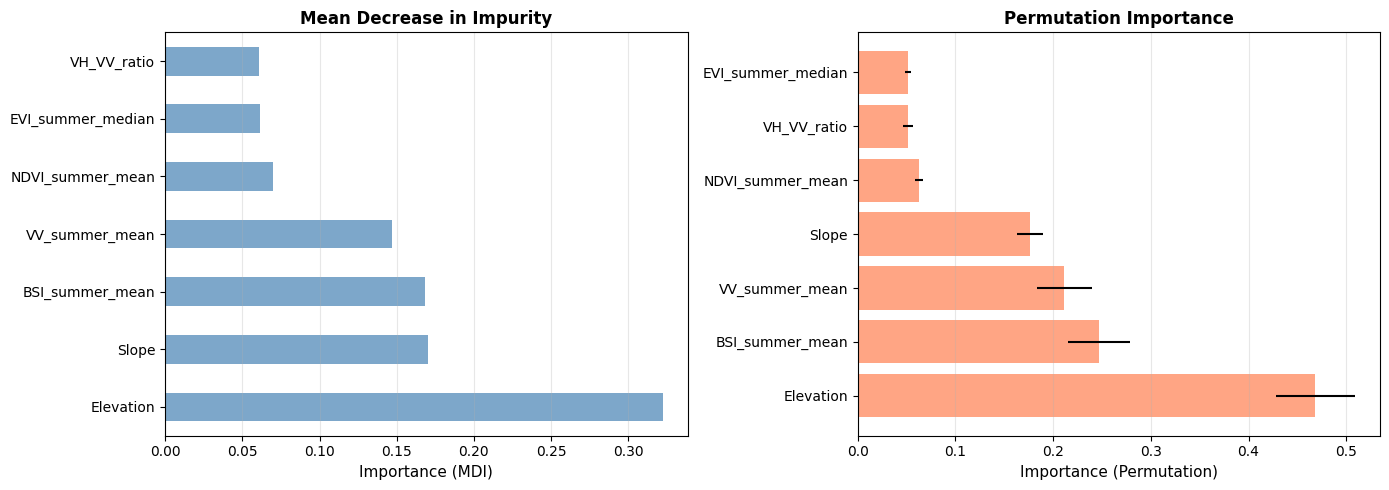

In [39]:
# Visualize variable importance
if len(fields_with_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # MDI importance
    ax = axes[0]
    mdi_importance.plot(x='variable', y='importance_MDI', kind='barh', ax=ax, 
                        color='steelblue', alpha=0.7, legend=False)
    ax.set_xlabel('Importance (MDI)', fontsize=11)
    ax.set_ylabel('')
    ax.set_title('Mean Decrease in Impurity', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Permutation importance
    ax = axes[1]
    ax.barh(perm_df['variable'], perm_df['importance_perm'], 
            xerr=perm_df['std'], color='coral', alpha=0.7)
    ax.set_xlabel('Importance (Permutation)', fontsize=11)
    ax.set_ylabel('')
    ax.set_title('Permutation Importance', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 3.3 Approach 3: Clustering Mimicry

Test which environmental variables best reproduce the spatial clustering of SOC values.

**Logic**: 
1. Cluster SOC values within each field (ground truth heterogeneity)
2. Cluster environmental variables (potential stratification basis)
3. Compare clustering agreement using Adjusted Rand Index (ARI)

**Interpretation**: Variables with high ARI can reproduce SOC spatial patterns → good for stratification.

**Limitations**:
- Each variable tested separately against SOC clusters
- Identifies which single variable best reproduces SOC spatial patterns

**Potential future work**:
We should add a multi-variable clustering mimicry test to Section 3.3:

Test all possible 2-variable combinations
Test top 3 variables combined
Compare if combinations reproduce SOC patterns better than individual variables

In [40]:
# Perform clustering analysis per field
clustering_results = []

for field_num in fields_with_data:
    if field_num not in soc_variables:
        continue
    
    df_field = soc_variables[field_num].dropna(subset=var_cols + ['SOC_value'])
    
    if len(df_field) < 10:  # Need sufficient samples
        print(f"Field {field_num}: Not enough samples ({len(df_field)}), skipping")
        continue
    
    print(f"\nField {field_num} - Clustering Analysis (n={len(df_field)})")
    
    # Determine optimal number of clusters (2-4 for soil sampling)
    n_clusters_range = range(2, min(5, len(df_field)//3))
    
    # 1. Cluster SOC values (ground truth)
    soc_scaler = StandardScaler()
    soc_scaled = soc_scaler.fit_transform(df_field[['SOC_value']])
    
    # Find optimal k for SOC
    silhouette_scores = []
    for k in n_clusters_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(soc_scaled)
        sil_score = silhouette_score(soc_scaled, labels)
        silhouette_scores.append(sil_score)
    
    optimal_k = list(n_clusters_range)[np.argmax(silhouette_scores)]
    print(f"  Optimal clusters for SOC: {optimal_k} (silhouette={max(silhouette_scores):.3f})")
    
    # Cluster SOC with optimal k
    kmeans_soc = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    soc_clusters = kmeans_soc.fit_predict(soc_scaled)
    
    # 2. Test each variable individually
    for var in var_cols:
        if df_field[var].isna().all():
            continue
        
        # Scale variable
        var_scaler = StandardScaler()
        var_scaled = var_scaler.fit_transform(df_field[[var]])
        
        # Cluster variable with same k as SOC
        kmeans_var = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        var_clusters = kmeans_var.fit_predict(var_scaled)
        
        # Calculate ARI (how well variable clusters match SOC clusters)
        ari = adjusted_rand_score(soc_clusters, var_clusters)
        
        clustering_results.append({
            'field': field_num,
            'variable': var,
            'n_clusters': optimal_k,
            'ARI': ari,
            'n_samples': len(df_field)
        })
        
        print(f"    {var:20s}: ARI = {ari:.3f}")

# Convert to DataFrame
df_clustering = pd.DataFrame(clustering_results)
print(f"\nCompleted clustering analysis")


Field 1 - Clustering Analysis (n=40)
  Optimal clusters for SOC: 3 (silhouette=0.593)
    NDVI_summer_mean    : ARI = -0.015
    EVI_summer_median   : ARI = -0.035
    BSI_summer_mean     : ARI = -0.024
    Elevation           : ARI = 0.035
    Slope               : ARI = -0.043
    VV_summer_mean      : ARI = -0.006
    VH_VV_ratio         : ARI = -0.045

Field 2 - Clustering Analysis (n=39)
  Optimal clusters for SOC: 4 (silhouette=0.590)
    NDVI_summer_mean    : ARI = 0.071
    EVI_summer_median   : ARI = 0.031
    BSI_summer_mean     : ARI = 0.088
    Elevation           : ARI = -0.018
    Slope               : ARI = 0.043
    VV_summer_mean      : ARI = -0.002
    VH_VV_ratio         : ARI = -0.015

Field 3 - Clustering Analysis (n=85)
  Optimal clusters for SOC: 2 (silhouette=0.695)
    NDVI_summer_mean    : ARI = 0.131
    EVI_summer_median   : ARI = 0.011
    BSI_summer_mean     : ARI = 0.039
    Elevation           : ARI = 0.016
    Slope               : ARI = 0.062
    VV_s

In [41]:
# Summarize clustering results across all fields
if len(clustering_results) > 0:
    # Average ARI per variable
    ari_summary = df_clustering.groupby('variable')['ARI'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
    
    print("\n CLUSTERING MIMICRY RESULTS (Average ARI across fields)\n")
    print("Higher ARI = Variable clusters match SOC clusters better\n")
    
    for var in ari_summary.index:
        mean_ari = ari_summary.loc[var, 'mean']
        std_ari = ari_summary.loc[var, 'std']
        n_fields = int(ari_summary.loc[var, 'count'])
        
        quality = "Excellent" if mean_ari > 0.5 else "Good" if mean_ari > 0.3 else "Moderate" if mean_ari > 0.1 else "Poor"
        print(f"  {var:20s}: {mean_ari:6.3f} ± {std_ari:.3f}  ({quality}, n={n_fields} fields)")


 CLUSTERING MIMICRY RESULTS (Average ARI across fields)

Higher ARI = Variable clusters match SOC clusters better

  Elevation           :  0.077 ± 0.127  (Poor, n=5 fields)
  EVI_summer_median   :  0.045 ± 0.071  (Poor, n=5 fields)
  NDVI_summer_mean    :  0.016 ± 0.098  (Poor, n=5 fields)
  VV_summer_mean      :  0.008 ± 0.030  (Poor, n=5 fields)
  BSI_summer_mean     :  0.003 ± 0.084  (Poor, n=5 fields)
  VH_VV_ratio         : -0.011 ± 0.072  (Poor, n=5 fields)
  Slope               : -0.013 ± 0.072  (Poor, n=5 fields)


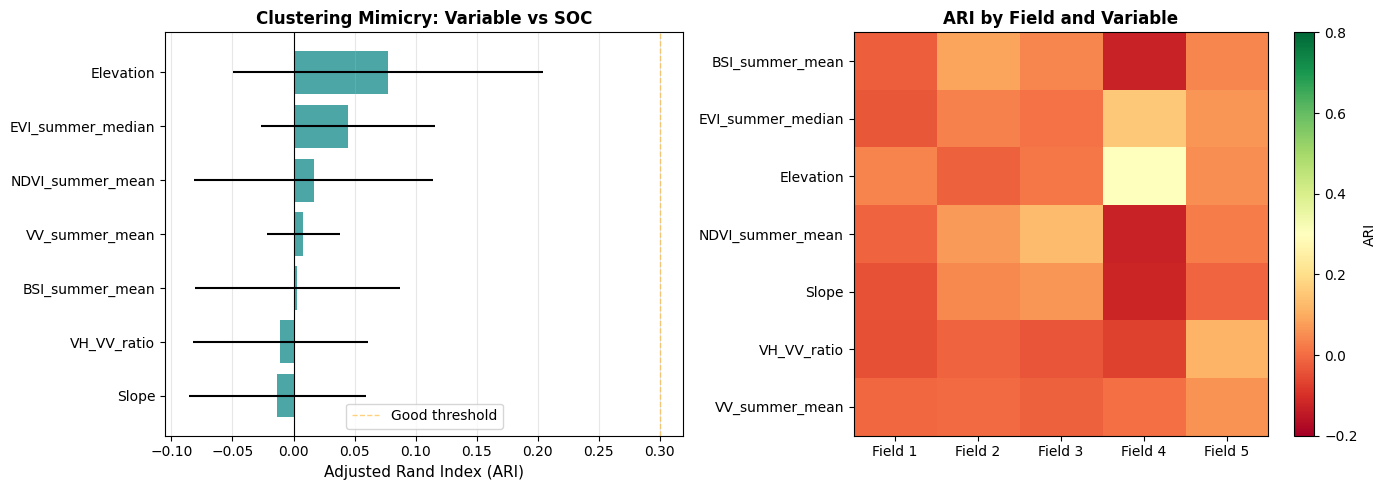

In [42]:
# Visualize clustering mimicry results
if len(clustering_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Average ARI per variable
    ax = axes[0]
    ari_summary_plot = ari_summary.sort_values('mean')
    ax.barh(ari_summary_plot.index, ari_summary_plot['mean'], 
            xerr=ari_summary_plot['std'], color='teal', alpha=0.7)
    ax.set_xlabel('Adjusted Rand Index (ARI)', fontsize=11)
    ax.set_ylabel('')
    ax.set_title('Clustering Mimicry: Variable vs SOC', fontsize=12, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.axvline(x=0.3, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Good threshold')
    ax.grid(axis='x', alpha=0.3)
    ax.legend()
    
    # ARI by field (heatmap)
    ax = axes[1]
    pivot = df_clustering.pivot(index='variable', columns='field', values='ARI')
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-0.2, vmax=0.8)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'Field {f}' for f in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('ARI by Field and Variable', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='ARI')
    
    plt.tight_layout()
    plt.show()

### 3.4 Variable Selection Summary

Compare results from all three approaches to identify robust variables for stratification.

In [43]:
# Create comprehensive comparison table
if len(fields_with_data) > 0 and len(clustering_results) > 0:
    # Normalize all metrics to 0-1 scale for comparison
    comparison = pd.DataFrame({'variable': var_cols})
    
    # 1. Correlation (absolute value, normalized)
    corr_dict = correlations_with_soc.abs().to_dict()
    comparison['correlation'] = comparison['variable'].map(corr_dict)
    comparison['correlation_norm'] = comparison['correlation'] / comparison['correlation'].max()
    
    # 2. Random Forest importance (already 0-1)
    rf_dict = dict(zip(mdi_importance['variable'], mdi_importance['importance_MDI']))
    comparison['rf_importance'] = comparison['variable'].map(rf_dict)
    comparison['rf_importance_norm'] = comparison['rf_importance'] / comparison['rf_importance'].max()
    
    # 3. Clustering ARI (convert to 0-1, ARI can be negative)
    ari_dict = ari_summary['mean'].to_dict()
    comparison['clustering_ARI'] = comparison['variable'].map(ari_dict)
    # Shift to positive and normalize
    ari_min = comparison['clustering_ARI'].min()
    comparison['clustering_norm'] = (comparison['clustering_ARI'] - min(0, ari_min)) / \
                                     (comparison['clustering_ARI'].max() - min(0, ari_min))
    
    # Calculate composite score (average of normalized metrics)
    comparison['composite_score'] = comparison[['correlation_norm', 'rf_importance_norm', 'clustering_norm']].mean(axis=1)
    
    # Rank variables
    comparison = comparison.sort_values('composite_score', ascending=False)
    
    print("\n VARIABLE SELECTION SUMMARY\n")
    print("Normalized scores (0-1 scale) from three approaches:\n")
    print(f"{'Variable':<20} {'Correlation':<12} {'RF Importance':<15} {'Clustering':<12} {'Composite':<10}")
    print("-" * 80)
    
    for _, row in comparison.iterrows():
        print(f"{row['variable']:<20} {row['correlation_norm']:>10.3f}  {row['rf_importance_norm']:>13.3f}  "
              f"{row['clustering_norm']:>10.3f}  {row['composite_score']:>8.3f}")
    
    print("\n Top 3 variables for stratification:")
    for i, row in comparison.head(3).iterrows():
        print(f"  {i+1}. {row['variable']} (score: {row['composite_score']:.3f})")


 VARIABLE SELECTION SUMMARY

Normalized scores (0-1 scale) from three approaches:

Variable             Correlation  RF Importance   Clustering   Composite 
--------------------------------------------------------------------------------
Elevation                 0.875          1.000       1.000     0.958
BSI_summer_mean           1.000          0.523       0.181     0.568
EVI_summer_median         0.825          0.191       0.641     0.552
VV_summer_mean            0.884          0.457       0.235     0.525
NDVI_summer_mean          0.885          0.217       0.328     0.476
Slope                     0.627          0.528       0.000     0.385
VH_VV_ratio               0.117          0.188       0.029     0.111

 Top 3 variables for stratification:
  4. Elevation (score: 0.958)
  3. BSI_summer_mean (score: 0.568)
  2. EVI_summer_median (score: 0.552)


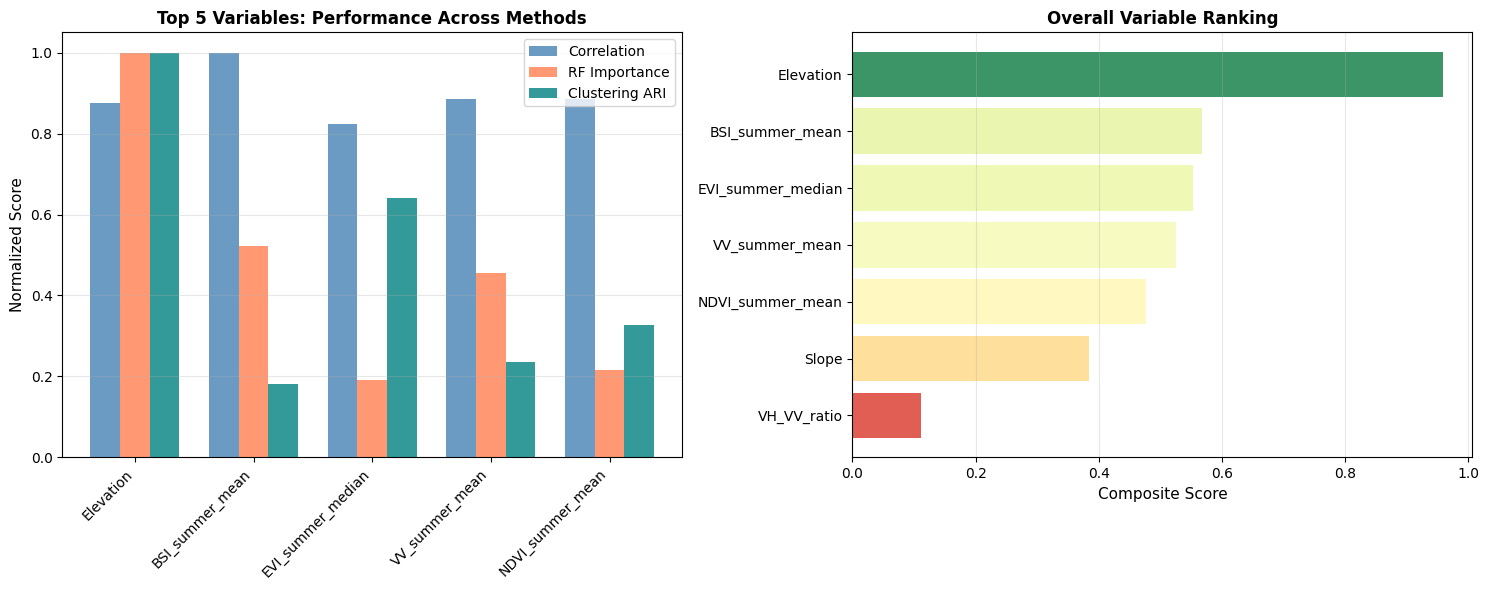

In [44]:
# Visualize comprehensive comparison
if len(fields_with_data) > 0 and len(clustering_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Radar chart of top variables
    ax = axes[0]
    comparison_top = comparison.head(5)
    x = np.arange(len(comparison_top))
    width = 0.25
    
    ax.bar(x - width, comparison_top['correlation_norm'], width, label='Correlation', alpha=0.8, color='steelblue')
    ax.bar(x, comparison_top['rf_importance_norm'], width, label='RF Importance', alpha=0.8, color='coral')
    ax.bar(x + width, comparison_top['clustering_norm'], width, label='Clustering ARI', alpha=0.8, color='teal')
    
    ax.set_ylabel('Normalized Score', fontsize=11)
    ax.set_title('Top 5 Variables: Performance Across Methods', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_top['variable'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Composite score ranking
    ax = axes[1]
    comparison_sorted = comparison.sort_values('composite_score')
    colors = plt.cm.RdYlGn(comparison_sorted['composite_score'].values)
    ax.barh(comparison_sorted['variable'], comparison_sorted['composite_score'], color=colors, alpha=0.8)
    ax.set_xlabel('Composite Score', fontsize=11)
    ax.set_ylabel('')
    ax.set_title('Overall Variable Ranking', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 4. Stratified Sampling Design & Evaluation

Apply stratified sampling strategy using selected variables and evaluate heterogeneity capture.

**Approach from smartsampling.ipynb:**
1. Use top-ranked variables for k-means clustering
2. Apply power analysis to determine sample size per stratum
3. Evaluate: Does stratification capture field SOC heterogeneity better than random sampling?

### 4.1 Define Stratification Strategy

Use top 2-3 variables identified from previous analysis.

The number of strata is determined by how well the field can be divided into distinct zones in the 3-variable space (Elevation + BSI + EVI).


_Real-world examples_:
- Field with high elevation range + strong BSI gradient:
    Distinct zones: high/dry hilltop, mid-slope, low/wet valley
    Silhouette favors k=3 or 4 strata
    Field that's flat + homogeneous vegetation:

- Weak gradients, fuzzy boundaries
    Silhouette favors k=2 strata (just high/low)

_Why this imakes sense_:

Avoids forcing 4 strata on a homogeneous field (overfitting) and avoids using only 2 strata when field has clear environmental zones (underfitting)

In [45]:
# Select top variables for stratification
if len(fields_with_data) > 0 and len(clustering_results) > 0:
    # Get top 3 variables
    top_variables = comparison.head(3)['variable'].tolist()
    
    print(f"Selected variables for stratification:")
    for i, var in enumerate(top_variables, 1):
        score = comparison[comparison['variable'] == var]['composite_score'].values[0]
        print(f"  {i}. {var} (composite score: {score:.3f})")
    
    # For each field, create stratification based on these variables
    stratification_results = {}
    
    for field_num in fields_with_data:
        if field_num not in soc_variables:
            continue
        
        df_field = soc_variables[field_num].dropna(subset=top_variables + ['SOC_value'])
        
        if len(df_field) < 10:
            continue
        
        print(f"\nField {field_num}: Creating stratification (n={len(df_field)})")
        
        # Scale variables
        scaler = StandardScaler()
        X_strat = scaler.fit_transform(df_field[top_variables])
        
        # Try different numbers of strata (2-4)
        best_strata = None
        best_score = -1
        
        for n_strata in range(2, min(5, len(df_field)//3)):
            kmeans = KMeans(n_clusters=n_strata, random_state=42, n_init=10)
            strata_labels = kmeans.fit_predict(X_strat)
            
            # Evaluate: silhouette score
            sil_score = silhouette_score(X_strat, strata_labels)
            
            if sil_score > best_score:
                best_score = sil_score
                best_strata = n_strata
                best_labels = strata_labels
        
        stratification_results[field_num] = {
            'n_strata': best_strata,
            'labels': best_labels,
            'silhouette': best_score,
            'data': df_field
        }
        
        print(f"  Optimal strata: {best_strata} (silhouette={best_score:.3f})")

Selected variables for stratification:
  1. Elevation (composite score: 0.958)
  2. BSI_summer_mean (composite score: 0.568)
  3. EVI_summer_median (composite score: 0.552)

Field 1: Creating stratification (n=40)
  Optimal strata: 2 (silhouette=0.392)

Field 2: Creating stratification (n=40)
  Optimal strata: 3 (silhouette=0.425)

Field 3: Creating stratification (n=85)
  Optimal strata: 2 (silhouette=0.436)

Field 4: Creating stratification (n=20)
  Optimal strata: 2 (silhouette=0.413)

Field 5: Creating stratification (n=37)
  Optimal strata: 4 (silhouette=0.444)


### 4.2 Evaluate Heterogeneity Capture

**Question**: Does stratified sampling capture SOC heterogeneity better than random sampling?

**Evaluation metrics:**
- **Within-strata variance**: Lower is better (homogeneous strata)
- **Between-strata variance**: Higher is better (distinct strata)
- **F-statistic**: Ratio of between/within variance
- **Coverage**: Do strata span the full SOC range?

In [46]:
# Evaluate stratification quality
if len(stratification_results) > 0:
    print("\n STRATIFICATION EVALUATION\n")
    
    for field_num, result in stratification_results.items():
        df_field = result['data']
        strata_labels = result['labels']
        n_strata = result['n_strata']
        
        print(f"\nField {field_num} - {n_strata} strata:")
        
        # Add strata labels to dataframe
        df_field_strata = df_field.copy()
        df_field_strata['stratum'] = strata_labels
        
        # Calculate variance decomposition
        # Total variance
        total_var = df_field_strata['SOC_value'].var()
        
        # Within-strata variance (weighted average)
        within_var = 0
        for stratum in range(n_strata):
            stratum_data = df_field_strata[df_field_strata['stratum'] == stratum]['SOC_value']
            n_stratum = len(stratum_data)
            within_var += (n_stratum / len(df_field_strata)) * stratum_data.var()
        
        # Between-strata variance
        between_var = total_var - within_var
        
        # F-statistic (ANOVA)
        strata_groups = [df_field_strata[df_field_strata['stratum'] == i]['SOC_value'].values 
                        for i in range(n_strata)]
        f_stat, p_value = scipy_stats.f_oneway(*strata_groups)
        
        # Variance explained by stratification
        var_explained = between_var / total_var * 100
        
        print(f"  Total variance: {total_var:.4f}")
        print(f"  Within-strata variance: {within_var:.4f} ({within_var/total_var*100:.1f}%)")
        print(f"  Between-strata variance: {between_var:.4f} ({var_explained:.1f}%)")
        print(f"  F-statistic: {f_stat:.2f} (p={p_value:.4f})")
        print(f"  → Stratification explains {var_explained:.1f}% of SOC variance")
        
        # Show SOC distribution per stratum
        print(f"\n  SOC distribution per stratum:")
        for stratum in range(n_strata):
            stratum_soc = df_field_strata[df_field_strata['stratum'] == stratum]['SOC_value']
            print(f"    Stratum {stratum+1} (n={len(stratum_soc):2d}): "
                  f"{stratum_soc.mean():.2f} ± {stratum_soc.std():.2f}%, "
                  f"range=[{stratum_soc.min():.2f}, {stratum_soc.max():.2f}]")


 STRATIFICATION EVALUATION


Field 1 - 2 strata:
  Total variance: 0.0204
  Within-strata variance: 0.0204 (99.9%)
  Between-strata variance: 0.0000 (0.1%)
  F-statistic: 0.82 (p=0.3714)
  → Stratification explains 0.1% of SOC variance

  SOC distribution per stratum:
    Stratum 1 (n=14): 0.90 ± 0.11%, range=[0.79, 1.15]
    Stratum 2 (n=26): 0.95 ± 0.16%, range=[0.64, 1.30]

Field 2 - 3 strata:
  Total variance: 0.0138
  Within-strata variance: 0.0096 (69.1%)
  Between-strata variance: 0.0043 (30.9%)
  F-statistic: 9.77 (p=0.0004)
  → Stratification explains 30.9% of SOC variance

  SOC distribution per stratum:
    Stratum 1 (n=19): 0.69 ± 0.09%, range=[0.53, 0.84]
    Stratum 2 (n=10): 0.83 ± 0.10%, range=[0.71, 0.99]
    Stratum 3 (n=11): 0.82 ± 0.11%, range=[0.63, 0.99]

Field 3 - 2 strata:
  Total variance: 0.0997
  Within-strata variance: 0.0905 (90.8%)
  Between-strata variance: 0.0092 (9.2%)
  F-statistic: 10.12 (p=0.0021)
  → Stratification explains 9.2% of SOC variance

  

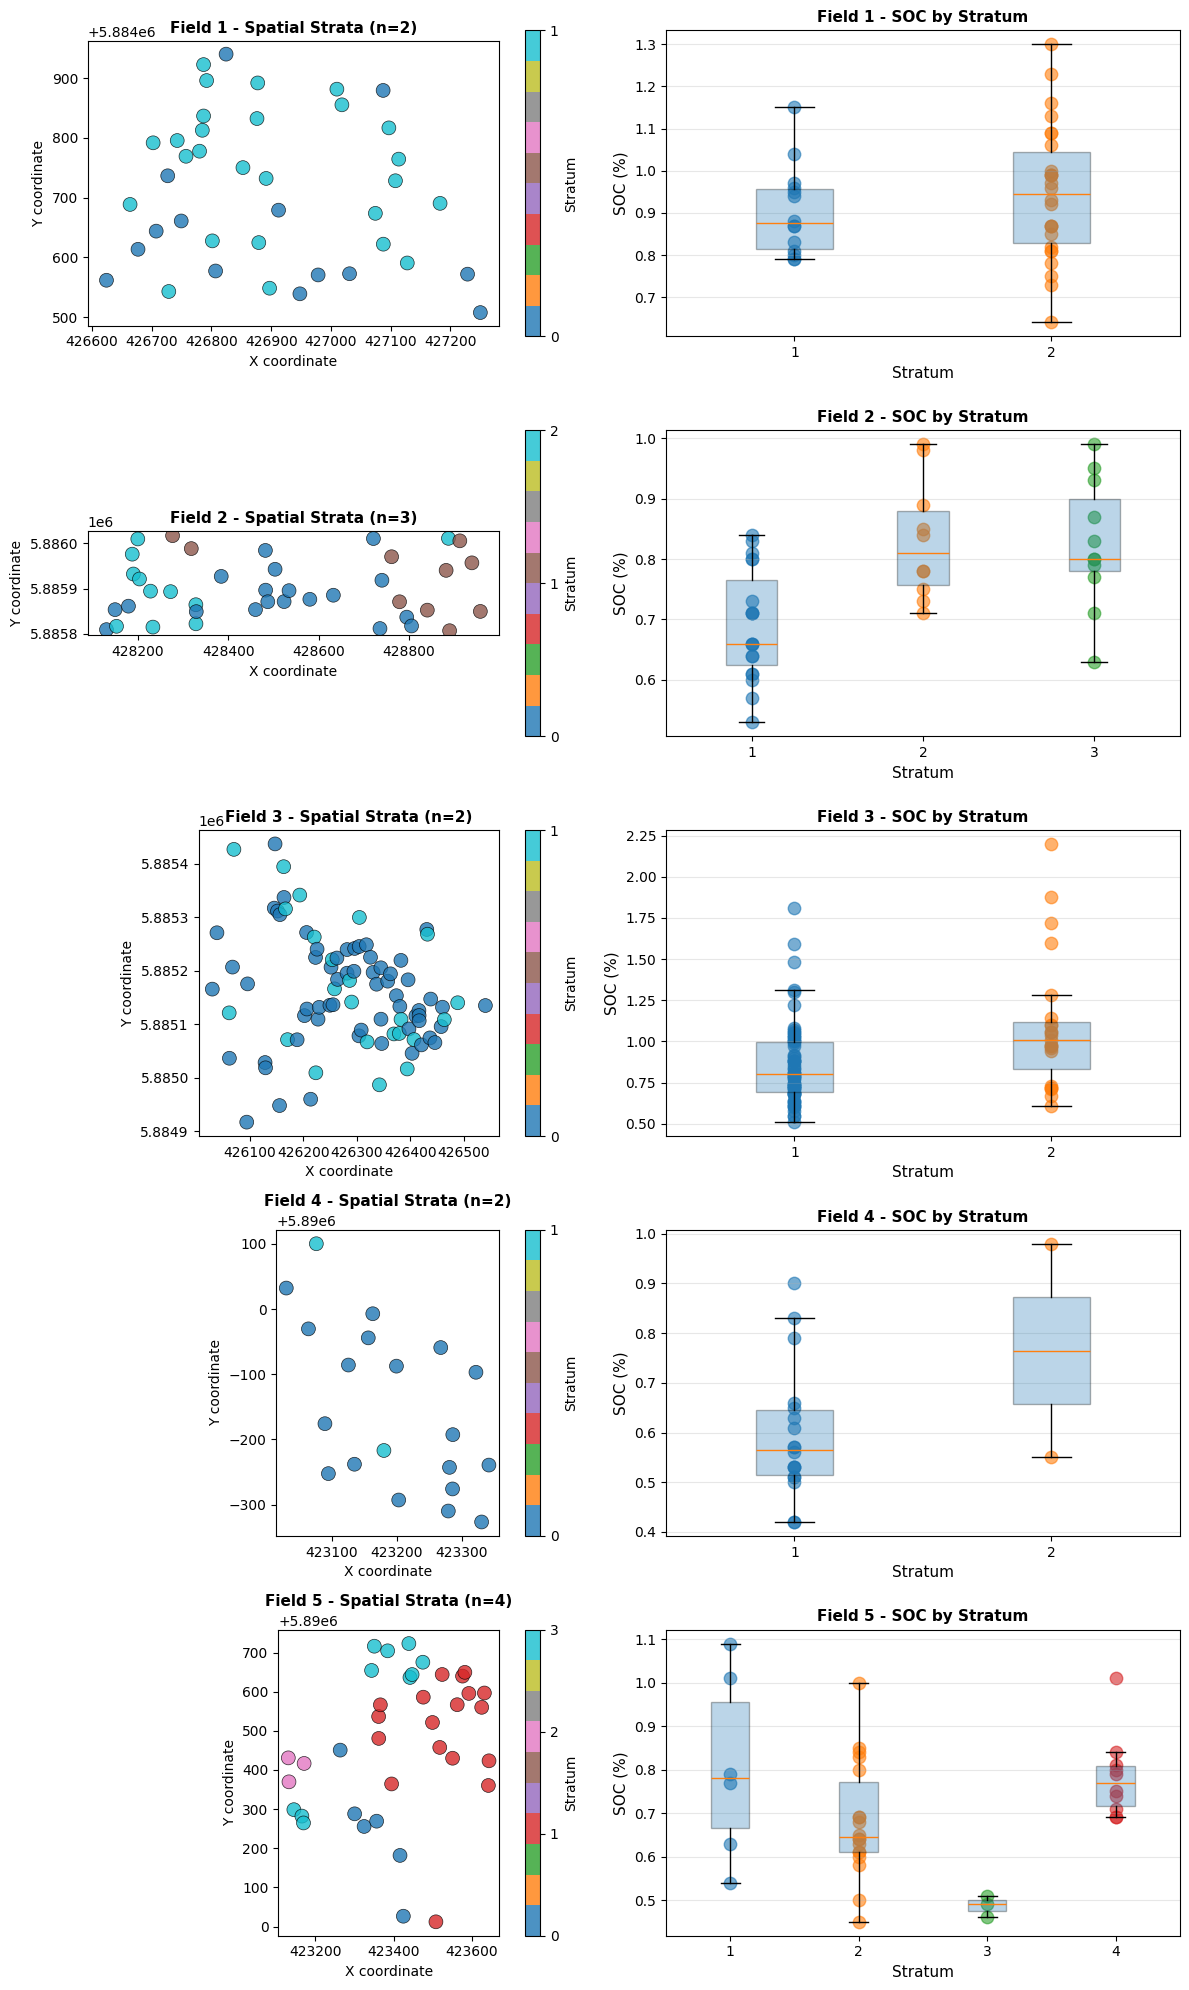

In [47]:
# Visualize stratification for each field
if len(stratification_results) > 0:
    n_fields = len(stratification_results)
    fig, axes = plt.subplots(n_fields, 2, figsize=(12, 4*n_fields))
    
    if n_fields == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (field_num, result) in enumerate(stratification_results.items()):
        df_field = result['data']
        df_field['stratum'] = result['labels']
        n_strata = result['n_strata']
        
        # Spatial map of strata
        ax = axes[idx, 0]
        scatter = ax.scatter(df_field['X'], df_field['Y'], c=df_field['stratum'], 
                            cmap='tab10', s=100, edgecolor='black', linewidth=0.5, alpha=0.8)
        ax.set_title(f'Field {field_num} - Spatial Strata (n={n_strata})', fontweight='bold', fontsize=11)
        ax.set_xlabel('X coordinate')
        ax.set_ylabel('Y coordinate')
        ax.set_aspect('equal')
        plt.colorbar(scatter, ax=ax, label='Stratum', ticks=range(n_strata))
        
        # SOC distribution by stratum
        ax = axes[idx, 1]
        for stratum in range(n_strata):
            stratum_soc = df_field[df_field['stratum'] == stratum]['SOC_value']
            ax.scatter([stratum+1]*len(stratum_soc), stratum_soc, 
                      alpha=0.6, s=80, label=f'Stratum {stratum+1}')
        
        # Add boxplot overlay
        strata_data = [df_field[df_field['stratum'] == i]['SOC_value'].values for i in range(n_strata)]
        bp = ax.boxplot(strata_data, positions=range(1, n_strata+1), widths=0.3, 
                       patch_artist=True, showfliers=False, boxprops=dict(alpha=0.3))
        
        ax.set_xlabel('Stratum', fontsize=11)
        ax.set_ylabel('SOC (%)', fontsize=11)
        ax.set_title(f'Field {field_num} - SOC by Stratum', fontweight='bold', fontsize=11)
        ax.set_xticks(range(1, n_strata+1))
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Summary & Conclusions

### Key Findings

**Variable Selection:**
- Three complementary approaches (correlation, RF, clustering) 
- Variables performing well across all methods would be the most reliable for stratification

**Stratification Performance:**
- Variance explained by stratification indicates effectiveness
- F-statistic significance shows if strata are truly distinct
- Spatial visualization reveals if stratification captures field heterogeneity

### Next Steps

1. **Extend to Brandenburg Farm 2** - Train and validate findings on independent dataset
2. **Multi-variable stratification** - Test combinations of top 2-3 variables
3. **Power analysis** - Determine optimal sample size per stratum (from smartsampling.ipynb)
4. **Temporal stability** - Test if stratification remains valid across years
5. **Scale to all pilots** - Apply methodology to broader dataset